=== DATA HEAD ===
         Date   Close    High     Low    Open  Volume
0  2016-01-19  14.110  14.110  14.065  14.065       3
1  2016-01-20  14.147  14.147  14.147  14.147       1
2  2016-01-21  14.083  14.083  14.083  14.083       2
3  2016-01-22  14.043  14.290  14.043  14.290       7
4  2016-01-25  14.240  14.240  14.095  14.095       8

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2514 non-null   object 
 1   Close   2514 non-null   float64
 2   High    2514 non-null   float64
 3   Low     2514 non-null   float64
 4   Open    2514 non-null   float64
 5   Volume  2514 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 118.0+ KB
None

=== MISSING VALUES ===
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


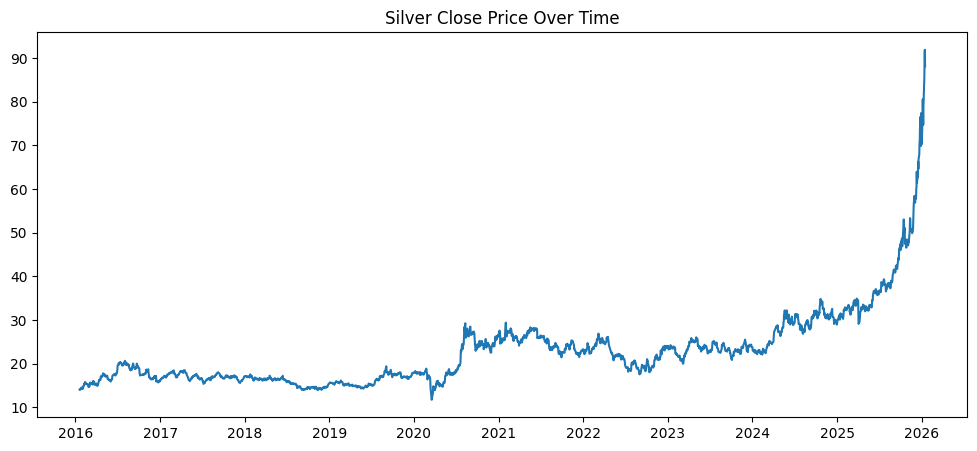

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 0.0022
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 2.2720e-04
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 2.0064e-04
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 1.6708e-04
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 1.6651e-04
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1.4816e-04
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1.3709e-04
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 1.2978e-04
Epoch 9/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 1.2579e-04
Epoch 10/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 1.1953e-04
Epoch 11/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 1.1465e-04
Epoch 12/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1.2954e-04
Epoch 13/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 1.1261e-04
Epoch 14/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 1.0489e-04
Epoch 15/20
61/61 ━━━━━━━━━━━━

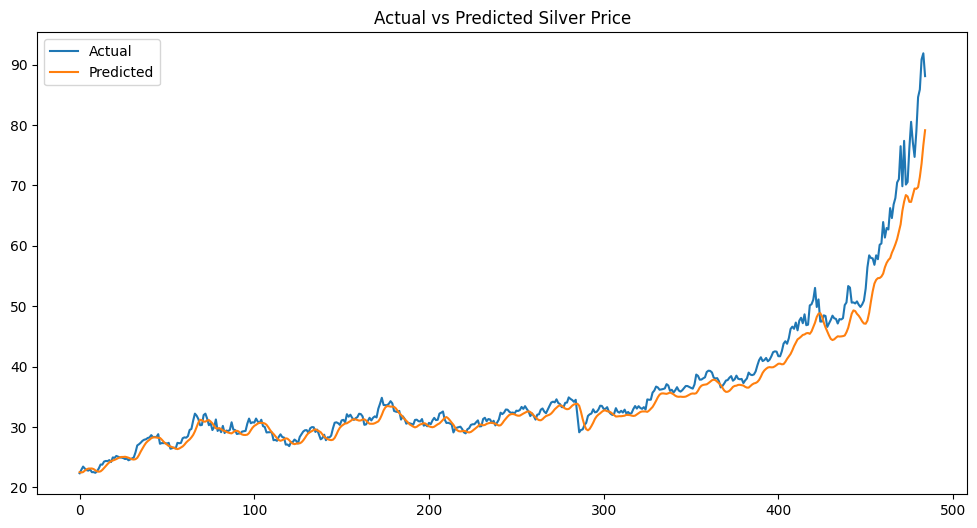

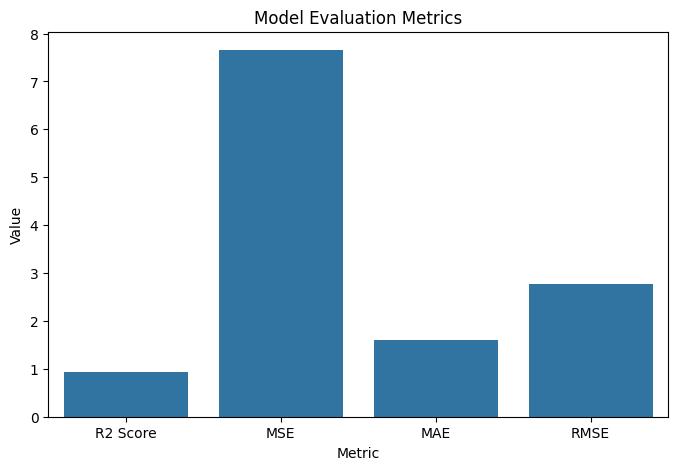

In [2]:
#Silver Price Prediction - Full ML Pipeline
#EDA -> Preprocessing -> Feature Engineering -> Modeling -> Evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# สำรวจข้อมูล (EDA)
data = pd.read_csv("../../Data/CSV/silver_prices_10years.csv")

print("=== DATA HEAD ===")
print(data.head())

print("\n=== DATA INFO ===")
print(data.info())

print("\n=== MISSING VALUES ===")
print(data.isnull().sum())

# แปลงวันที่
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# ดูกราฟราคาปิด
plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['Close'])
plt.title("Silver Close Price Over Time")
plt.show()


# เตรียมข้อมูล (Preprocessing)
# เลือกคอลัมน์ที่ใช้
data = data[['Date','Close','High','Low','Open','Volume']]

# ลบ missing (ถ้ามี)
data = data.dropna()


# Feature Engineering
# สร้าง Moving Average
data['MA10'] = data['Close'].rolling(window=10).mean()
data['MA30'] = data['Close'].rolling(window=30).mean()

# ลบ NaN จาก rolling
data = data.dropna()

# เลือก feature
features = ['Close','High','Low','Open','Volume','MA10','MA30']

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[features])


#สร้าง Time Series Dataset (60 วันย้อนหลัง)
sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i][0])  # ทำนาย Close

X = np.array(X)
y = np.array(y)

# แบ่ง Train/Test
train_size = int(len(X)*0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# สร้างโมเดล LSTM
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)


# ทำนาย
predictions = model.predict(X_test)

# แปลงกลับค่า Close จริง
close_index = features.index('Close')

# สร้าง array เต็มเพื่อ inverse
temp_pred = np.zeros((len(predictions), len(features)))
temp_pred[:, close_index] = predictions[:,0]

temp_true = np.zeros((len(y_test), len(features)))
temp_true[:, close_index] = y_test

predictions_actual = scaler.inverse_transform(temp_pred)[:,close_index]
y_test_actual = scaler.inverse_transform(temp_true)[:,close_index]

#ประเมินผลโมเดล
mse = mean_squared_error(y_test_actual, predictions_actual)
mae = mean_absolute_error(y_test_actual, predictions_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, predictions_actual)

# ตารางสรุปผล
results = pd.DataFrame({
    "Metric": ["R2 Score","MSE","MAE","RMSE"],
    "Value": [r2, mse, mae, rmse]
})
print("\n=== MODEL PERFORMANCE ===")
print(results)

#กราฟเปรียบเทียบราคา
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions_actual, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Silver Price")
plt.show()

#กราฟเปรียบเทียบ Metrics
plt.figure(figsize=(8,5))
sns.barplot(x="Metric", y="Value", data=results)
plt.title("Model Evaluation Metrics")
plt.show()
